# Encoding

you know that model will train only on the numerical data it's not taking any categorical values only numerical \
so we have to convert the categorical data to numerical data 
thats why we have to use the concept of encoding

1. label encoding 
2. one hot endcoding
3. ordinal encoding

# label encoding 
    every number will get the number like 
    cat -- 0 dog -- 1 parrot -- 2
    this are the thing that you have 
    every category will get a unique number 
    but the problem is that model will more prefer who has 2 number 
    thats the biggest problem of label encoding thats why in production we are not using label encoding

In [1]:
import numpy as np
import pandas as pd

In [9]:
df = pd.read_csv('customer.csv')

In [10]:
df.sample(5)

,age,gender,review,education,purchased
2,70,Female,Good,PG,No
1,68,Female,Poor,UG,No
7,60,Female,Poor,School,Yes
34,86,Male,Average,School,No
28,48,Male,Poor,School,No


In [11]:
df.head()

,age,gender,review,education,purchased
0,30,Female,Average,School,No
1,68,Female,Poor,UG,No
2,70,Female,Good,PG,No
3,72,Female,Good,PG,No
4,16,Female,Average,UG,No


In [12]:
df = df.iloc[:,2:]

In [14]:
df.head()

,review,education,purchased
0,Average,School,No
1,Poor,UG,No
2,Good,PG,No
3,Good,PG,No
4,Average,UG,No


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,0:2], df.iloc[:,0:2], test_size=0.2, random_state=0)

In [16]:
X_train.shape 

(40, 2)

In [17]:
X_test.shape

(10, 2)

In [27]:
df['review'].value_counts()

review
Poor       18
Good       18
Average    14
Name: count, dtype: int64

In [34]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

encoded = encoder.fit_transform(df['review'])

encoded

array([0, 2, 1, 1, 0, 0, 1, 2, 0, 1, 1, 1, 2, 0, 2, 2, 2, 2, 1, 2, 0, 0,
       2, 1, 0, 1, 2, 2, 2, 0, 0, 2, 0, 1, 0, 2, 1, 0, 1, 2, 1, 1, 1, 2,
       0, 2, 2, 1, 1, 1])

In [18]:
from sklearn.preprocessing import OneHotEncoder

In [19]:
encoder = OneHotEncoder()

In [28]:
encoded = encoder.fit_transform(df[['review']])

In [29]:
encoded.toarray()

array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1

It reserves the natural order of the elements in the array for the purpose of keeping the data in a sorted order.

Since there is a natural ranking, assigning numbers makes sense.

yeh basically sensable order follow karta hai na ki label encoder jaise 

like jo natural existamce mein hai vaisa hi karta hia 

In [35]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

In [36]:
encoded = encoder.fit_transform(df[['review']])

In [ ]:
encoded   # here it will be giving the natural existancing order

array([[0.],
       [2.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [2.],
       [0.],
       [1.],
       [1.],
       [1.],
       [2.],
       [0.],
       [2.],
       [2.],
       [2.],
       [2.],
       [1.],
       [2.],
       [0.],
       [0.],
       [2.],
       [1.],
       [0.],
       [1.],
       [2.],
       [2.],
       [2.],
       [0.],
       [0.],
       [2.],
       [0.],
       [1.],
       [0.],
       [2.],
       [1.],
       [0.],
       [1.],
       [2.],
       [1.],
       [1.],
       [1.],
       [2.],
       [0.],
       [2.],
       [2.],
       [1.],
       [1.],
       [1.]])

the usefulness of this system will depend upon the quality of the data

what the question will be demanding from ur side 

it totally depends upon your data 

In [ ]:
ohe = OneHotEncoder(
    drop='first',   # YOU KNOW OHE WILL CREATE N COLUMNS FOR N CATEGORIES, SO TO AVOID THE DUMMY VARIABLE TRAP WE DROP ONE COLUMN
    sparse_output=False, #ohe returns always sparse matrix -- non zero thatswhy its store only non zero values
    handle_unknown='ignore'
)

In [ ]:
# lets understand the ordinal encoding how the order will be decided 

from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[['bad' , 'good' , 'very good' , 'execellent']]) # it will decide the order based on the categories 

encoder.fit_transform(df[['review']])

# Imputer

Now lets talking about the imputer like some time we misses some values in the data so we can use the imputer to fill missing value

In [38]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer = SimpleImputer(strategy='mean'
                        # , fill_value='Unknown'
                        ) #strategy='median' , strategy='most_frequent'

In [ ]:
X = imputer.fit_transform(df[['age']]) #you can also done from the 

# Column Transformation
For advance programmer

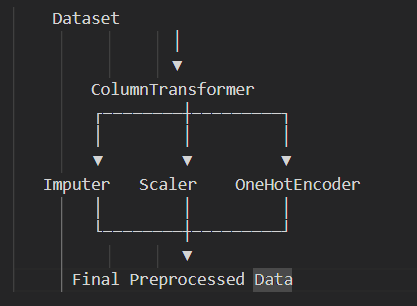

In [42]:
# Without ColumnTransformer, you'd have to preprocess each column separately and manually combine the results.
# With ColumnTransformer, everything is done in one place.

from sklearn.compose import ColumnTransformer



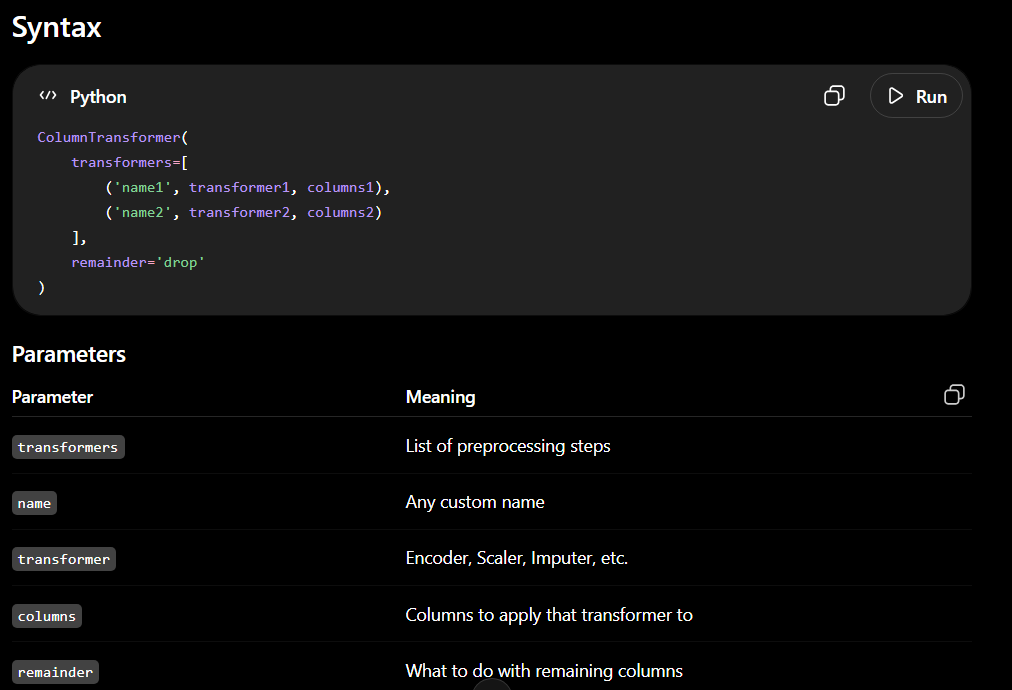

In [ ]:
transformer = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), ['age']),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['review'])
    ],
    remainder='passthrough'  # Keep the other columns unchanged
)

In [ ]:
transformer.fit_transform(X_train)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[
        ('gender_encoder',
         OneHotEncoder(drop='first'),
         ['Gender'])
    ],
    remainder='passthrough'
)

X = ct.fit_transform(df)

print(X)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ct = ColumnTransformer(
    transformers=[
        ('salary_scaler',
         StandardScaler(),
         ['Salary']),

        ('gender_ohe',
         OneHotEncoder(drop='first'),
         ['Gender']),

        ('city_ohe',
         OneHotEncoder(drop='first'),
         ['City'])
    ],
    remainder='passthrough'
)

# sklearn Pipelines

without pipeline you have to do the all stpes manually like all preprocessing steps and eda and lots of steps 

while this pipeline will be used to merge all steps together

# Project using pipeline

In [46]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.tree import DecisionTreeClassifier

In [47]:
df = pd.read_csv('tested.csv')

In [49]:
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
96,988,1,1,"Cavendish, Mrs. Tyrell William (Julia Florence...",female,76.0,1,0,19877,78.8500,C46,S
348,1240,0,2,"Giles, Mr. Ralph",male,24.0,0,0,248726,13.5000,NaN,S
168,1060,1,1,"Cassebeer, Mrs. Henry Arthur Jr (Eleanor Genev...",female,NaN,0,0,17770,27.7208,NaN,C


In [50]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [51]:
# Step 1 -> train/test/split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['Survived']),
                                                 df['Survived'],
                                                 test_size=0.2,
                                                random_state=42)

In [52]:
# imputation transformer
trf1 = ColumnTransformer([
    ('impute_age',SimpleImputer(),[2]),
    ('impute_embarked',SimpleImputer(strategy='most_frequent'),[6])
],remainder='passthrough')

In [53]:
trf2 = ColumnTransformer(
    transformers=[
        ('ohe_sex_embarked',
         OneHotEncoder(
             sparse_output=False,
             handle_unknown='ignore'
         ),
         [1, 6]   # Sex and Embarked column indices
        )
    ],
    remainder='passthrough'
)

In [54]:
# Scaling
trf3 = ColumnTransformer([
    ('scale',MinMaxScaler(),slice(0,10))
])

In [ ]:
# Feature selection
trf4 = SelectKBest(score_func=chi2,k=8) # it will giving the best feature selection based on the chi2 score

In [56]:
# train the model
trf5 = DecisionTreeClassifier()


In [57]:
pipe = Pipeline([
    ('trf1',trf1),
    ('trf2',trf2),
    ('trf3',trf3),
    ('trf4',trf4),
    ('trf5',trf5)
])

In [ ]:
# alternate syntax 
pipe = make_pipeline(trf1,trf2,trf3,trf4,trf5)

In [59]:
# train
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer-1', ...), ('columntransformer-2', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute_age', ...), ('impute_embarked', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, defau

In [60]:
# Code here
pipe.named_steps

{'columntransformer-1': ColumnTransformer(remainder='passthrough',
                   transformers=[('impute_age', SimpleImputer(), [2]),
                                 ('impute_embarked',
                                  SimpleImputer(strategy='most_frequent'),
                                  [6])]),
 'columntransformer-2': ColumnTransformer(remainder='passthrough',
                   transformers=[('ohe_sex_embarked',
                                  OneHotEncoder(handle_unknown='ignore',
                                                sparse_output=False),
                                  [1, 6])]),
 'columntransformer-3': ColumnTransformer(transformers=[('scale', MinMaxScaler(), slice(0, 10, None))]),
 'selectkbest': SelectKBest(k=8, score_func=<function chi2 at 0x0000021E5DF6E5C0>),
 'decisiontreeclassifier': DecisionTreeClassifier()}

In [62]:
# Display Pipeline

from sklearn import set_config
set_config(display='diagram')


In [64]:
# Predict
y_pred = pipe.predict(X_test)

In [65]:
y_pred

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [67]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)*100

59.523809523809526

Cross Validation -- it simply means that we split the data into two parts, one for training and one for testing. We then train the model on the training data and test it on the testing data. This process is repeated multiple times and the results are averaged. The more times we repeat the process, the more accurate the model will be.

In [68]:
from sklearn.model_selection import cross_val_score

In [ ]:
cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy').mean()

Gird Search Cv == GridSearchCV is used for Hyperparameter Tuning.
It automatically tries all possible combinations of hyperparameters, evaluates them using Cross Validation, and returns the best combination.

grid = GridSearchCV(
    estimator=pipe,
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

In [69]:
from sklearn.model_selection import GridSearchCV

In [70]:
# gridsearchcv
params = {
    'trf5__max_depth':[1,2,3,4,5,None]
}

    precision

    recall

    f1

    roc_auc

    neg_mean_squared_error

    r2

In [ ]:
grid = GridSearchCV(
    estimator=pipe, # you know we have pipe line then only the possible through which we can be grid search done
    param_grid=params,
    cv=5,# cross validation
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

    Predict through Pipeline

In [73]:
import pickle
import numpy as np

In [ ]:
pipe = pickle.load(open('pipe.pkl','rb'))

In [ ]:
# Assume user input
test_input2 = np.array([2, 'male', 31.0, 0, 0, 10.5, 'S'],dtype=object).reshape(1,7)

In [ ]:
pipe.predict(test_input2)

# Function Transformation

Function -- log , squareroot , reciprocal 

when u want to apply the any mathematical function on the whole feature/column --- 

When we use?
-Data is skewed
-Large Value dominate kar rhi ho 
-Distribution is not normal
-Linear model ki performance bad


# Log Transform
x' = log(x)
when -- 1. right skewed 2. value is large +ve case mein 

# Square Root Transform
x' = sqrt(x)
when -- 1. left skeweness 2. Count data 

# Reciprocal Transform
x' = 1/x
when -- 1. choti value badi ho jati and vice versa 

from sklearn.preprocessing import FunctionTransformer

In [2]:
pip show matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.3 MB 3.2 MB/s eta 0:00:03
   ---------- ----------------------------- 2.4/9.3 MB 4.2 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.3 MB 5.2 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.3 MB 6.1 MB/s eta 0:00:01
   ------------------------------------- -- 8.7/9.3 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 7.3 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip uninstall matplotlib -y

Found existing installation: matplotlib 3.11.1
Uninstalling matplotlib-3.11.1:
  Successfully uninstalled matplotlib-3.11.1
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.


In [8]:
pip install --no-cache-dir matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -------------- ------------------------- 3.4/9.3 MB 21.8 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 25.3 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 25.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


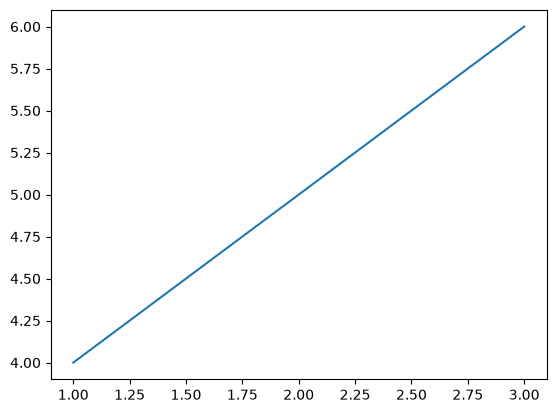

In [1]:
import matplotlib.pyplot as plt

plt.plot([1,2,3],[4,5,6])
plt.show()

In [2]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('tested.csv',usecols=['Age','Fare','Survived'])

In [4]:
df.isnull().sum()

Survived     0
Age         86
Fare         1
dtype: int64

In [5]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\Shubham Kumar\AppData\Local\Temp\ipykernel_31208\694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [6]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

C:\Users\Shubham Kumar\AppData\Local\Temp\ipykernel_31208\2888751792.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


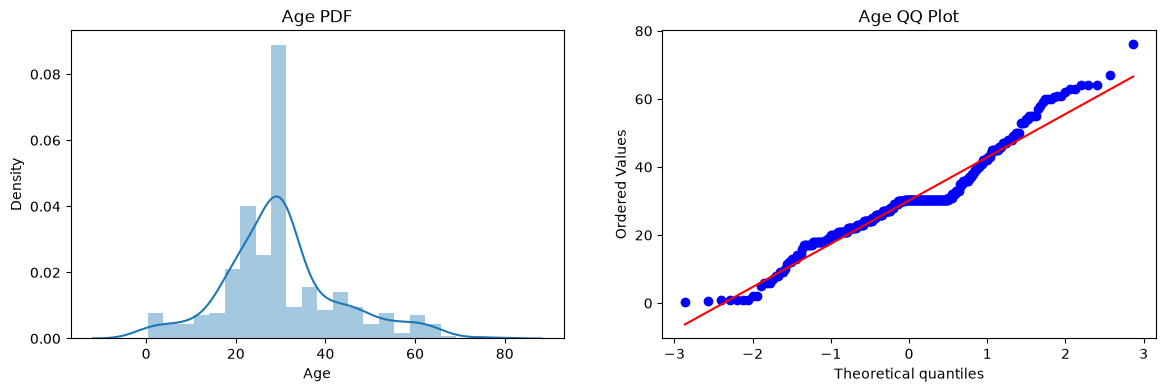

In [8]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

C:\Users\Shubham Kumar\AppData\Local\Temp\ipykernel_31208\2981780686.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


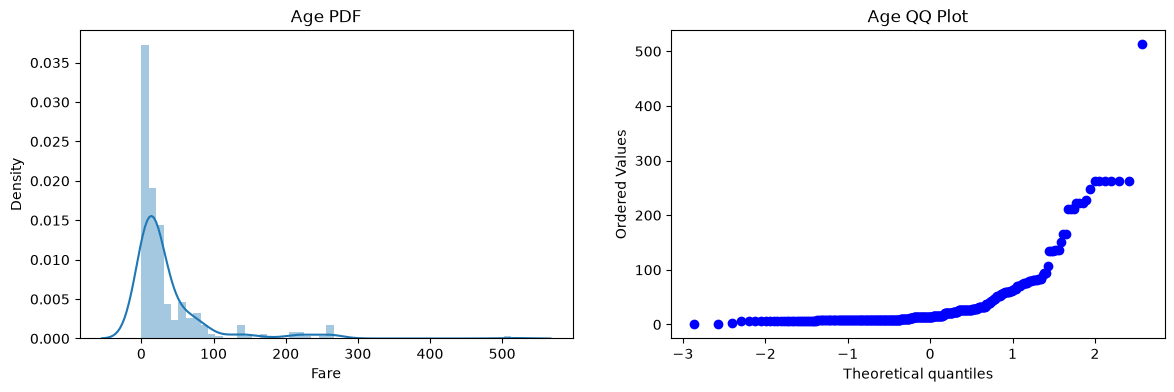

In [9]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [10]:
from sklearn.preprocessing import FunctionTransformer

stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)   # qq plot 

In [ ]:
trf = FunctionTransformer(func=np.log1p)

X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

#   Power Transformation

In [2]:
# What is Power Transform?

# A Power Transform is a mathematical technique used to make the data:

# More normally distributed (Gaussian)
# Reduce skewness
# Stabilize variance
# Improve the performance of ML algorithms that assume normality

# Think of it as a smart transformation that automatically chooses the best exponent for your data.